[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FM4CS/thor_terratorch_ext/blob/main/notebooks/thor_embedding_generation_sen1floods11.ipynb)

### Setup for Google Colab

If you are running this notebook in Google Colab, complete the following steps:

1. In Colab, we recommend going to **Runtime → Change runtime type** and selecting **T4 GPU**
2. Install the **TerraTorch THOR** extension and the required packages
3. Download the dataset (as part of the notebook)

In [ ]:
import os

IN_COLAB = bool(os.getenv("COLAB_RELEASE_TAG"))

if IN_COLAB:
    %pip install git+https://github.com/fm4cs/thor_terratorch_ext.git

------------

## Notebook: Embedding Generation with THOR in TerraTorch (Sen1Floods11)

This notebook shows how to generate dense spatial embeddings from Sentinel-2 imagery using the THOR foundation model via TerraTorch's `EmbeddingGenerationTask`. We use the Sen1Floods11 dataset as input, visualize the raw embeddings with PCA, and explore the spatial structure of the learned representations.

## Data Download

In [24]:
import gdown
import thor_terratorch_ext  # noqa: F401  — registers THOR backbones
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

In [ ]:
dataset_path = Path("../sen1floods11_v1.1")
archive_path = dataset_path.with_suffix(".tar.gz")

# Extract archive if dataset directory does not exist
if not dataset_path.exists():
    # Download archive if it does not exist
    if not archive_path.is_file():
        gdown.download(
            "https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS",
            str(archive_path),
            quiet=False,
        )
    !tar -xzf {archive_path} -C {dataset_path.parent}
!ls "{dataset_path}/data"

CopernicusDEM  JRCWaterHand  LabelHand	S1GRDHand  S1OtsuLabelHand  S2L1CHand


### Import the relevant components

We import the datamodule and task needed for this workflow:

- We use `GenericNonGeoSegmentationDataModule` to load the Sentinel-2 data. Labels aren't required and we will only use the predict workflow. The exact choice of datamodule is therefore not essential, as long as it is compatible with the input image format (e.g. using a multimodal datamodule for inputs with multiple modalities).
- Crucially, we use `EmbeddingGenerationTask` to extract and save embeddings, rather than training a downstream model directly.

In [26]:
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.tasks import EmbeddingGenerationTask

In [ ]:
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=4,
    num_workers=4,
    num_classes=2,  # Required by the datamodule; not used for embedding generation
    check_stackability=False,
    train_data_root=None,
    val_data_root=None,
    test_data_root=None,
    predict_data_root=dataset_path / "data/S2L1CHand",
    img_grep="*_S2Hand.tif",
    # All 13 Sentinel-2 L1C bands in the dataset
    dataset_bands=[
        "COASTAL_AEROSOL",  # B01
        "BLUE",  # B02
        "GREEN",  # B03
        "RED",  # B04
        "RED_EDGE_1",  # B05
        "RED_EDGE_2",  # B06
        "RED_EDGE_3",  # B07
        "NIR_BROAD",  # B08
        "NIR_NARROW",  # B8A
        "WATER_VAPOR",  # B09
        "CIRRUS",  # B10
        "SWIR_1",  # B11
        "SWIR_2",  # B12
    ],
    # Sen1Floods11 dataset statistics for all 13 bands
    means=[
        1626.916,
        1396.035,
        1364.061,
        1218.228,
        1466.073,
        2386.903,
        2845.613,
        2622.958,
        3077.482,
        486.874,
        63.779,
        2030.648,
        1179.166,
    ],
    stds=[
        700.171,
        739.095,
        735.248,
        864.937,
        776.880,
        921.368,
        1084.373,
        1022.634,
        1196.443,
        336.611,
        144.000,
        980.871,
        764.608,
    ],
    no_data_replace=0,
)

# Set up the datamodule for prediction
datamodule.setup("predict")

## Run Embedding Generation via TerraTorch CLI

We run `terratorch predict` using the provided config. This processes all prediction samples through the `thor_v1_tiny` backbone with 10 Sentinel-2 bands (Blue, Green, Red, NIR broad — 10 m GSD; RE1–RE3, NIR narrow, SWIR1–2 — 20 m GSD) and saves the output embeddings as GeoTIFF files. The two GSD groups are merged with `mean`, producing 192-channel feature maps at 72×72 spatial resolution per scene.

In [ ]:
model = EmbeddingGenerationTask(
    # Select and configure the THOR backbone
    model_args={
        "backbone": "thor_v1_tiny",
        "backbone_pretrained": True,
        "backbone_model_bands": [
            # 10 m GSD group
            "BLUE",
            "GREEN",
            "RED",
            "NIR_BROAD",
            # 20 m GSD group
            "RED_EDGE_1",
            "RED_EDGE_2",
            "RED_EDGE_3",
            "NIR_NARROW",
            "SWIR_1",
            "SWIR_2",
        ],
        "backbone_input_params": {
            "ground_covers": [
                2880
            ],  # 2880 m footprint → 288 px at 10 m, 144 px at 20 m GSD
            "flexivit_patch_size_seqs": [
                4
            ],  # 4 px patches → 72 patches/side at 10 m GSD
        },
        "backbone_merge_method": "mean",  # average the two GSD groups → C = 192
    },
    # Embedding workflow-specific configuration
    output_format="tiff",  # Save embeddings as GeoTIFFs
    output_dir="../output/embeddings_thor",
    layers=[-1],  # Extract the final encoder layer
    embedding_pooling=None,  # Keep dense spatial embeddings (recommended for pixel-wise tasks)
    has_cls=False,
)

In [29]:
# Before we generate the embeddings, we investigate the input and output shape to better understand the chosen configurations
dataloader = datamodule.predict_dataloader()

# We pick the first batch from our dataloader and extract the image input
batch = next(iter(dataloader))
images = batch["image"]

# Our model is confiugred with the FM backbone as well as a neck that aggregate and reshape the embeddings
outputs = model(images)

print(f"Input batch shape: {images.shape}")
print(
    f"Length of Outputs: {len(outputs)}"
)  # We requested only the final layer embedding so a list of len 1 is returned by the model
print(
    f"Input batch shape: {outputs[0].shape}"
)  # The output contains 384 channels (embedding size ViT-Small) and is reshaped to spatial grid as we chose tiff as output format

Input batch shape: torch.Size([4, 13, 512, 512])
Length of Outputs: 1
Input batch shape: torch.Size([4, 384, 72, 72])


In [30]:
# Generate embeddings
trainer = pl.Trainer(accelerator="auto")
_ = trainer.predict(model, datamodule=datamodule)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


Output()

INFO:EmbeddingGenerationTask:Configuration summary saved to ../output/embeddings_thor/configuration_summary.json


## Load and Explore Embeddings

Each embedding file is a GeoTIFF with shape `(C, H, W)` where `C=192` (2 GSD groups averaged via mean-merge, hidden dimension 192) and `H=W=72` spatial patches (from `ground_covers=2880` at 10 m GSD with `patch_size=4`: 2880 / 10 / 4 = 72 patches per side). We load one embedding and inspect its shape.

In [31]:
import rasterio
import numpy as np
from pathlib import Path

embed_dir = Path("../output/embeddings_thor/layer_00")
embed_files = sorted(embed_dir.glob("*_embedding.tif"))
print(f"Found {len(embed_files)} embedding files")


# Load a few embeddings
def load_embedding(path):
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)  # (C, H, W)


sample_path = embed_files[1]
emb = load_embedding(sample_path)
print(f"Embedding shape: {emb.shape}  (channels, height, width)")
print(f"Sample: {sample_path.name}")

Found 446 embedding files
Embedding shape: (384, 72, 72)  (channels, height, width)
Sample: Bolivia_129334_S2Hand_embedding.tif


## Corresponding Input Image

We load and show the RGB input image corresponding to the first embedding. The input images are 13-band Sentinel-2 L1C GeoTIFFs; we read bands B04 (Red), B03 (Green), and B02 (Blue) for visualization.

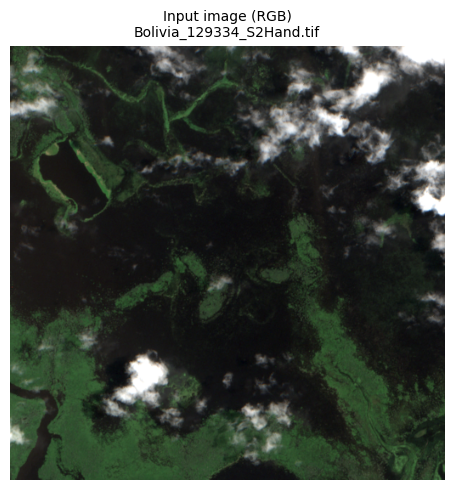

In [32]:
import matplotlib.pyplot as plt
from terratorch.datasets.utils import to_rgb

# Load the corresponding input image
img_name = sample_path.name.replace("_embedding.tif", ".tif")
img_path = dataset_path / "data/S2L1CHand" / img_name

with rasterio.open(img_path) as src:
    # Read bands B04 (Red), B03 (Green), B02 (Blue) = indices 3, 2, 1 (0-based)
    rgb = src.read([4, 3, 2]).astype(np.float32)  # (3, H, W)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(to_rgb(rgb, [0, 1, 2]))
ax.set_title(f"Input image (RGB)\n{img_name}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

## PCA Visualization of the Embedding

Since the embedding has 192 channels, we use PCA to reduce it to 3 components, which we display as an RGB image. This gives an intuitive view of the spatial structure learned by the THOR backbone — similar features in the scene will appear in similar colors.

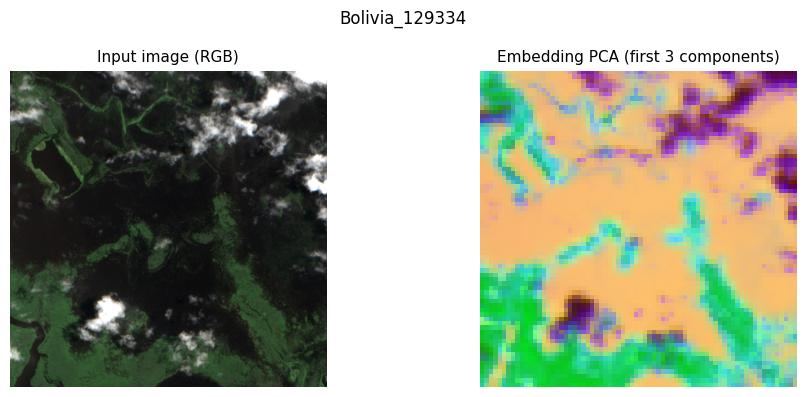

In [33]:
import numpy as np
from terratorch.datasets.utils import to_pca_rgb, to_rgb

pca_rgb, _, _ = to_pca_rgb(emb, step=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(to_rgb(rgb, [0, 1, 2]))
axes[0].set_title("Input image (RGB)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(pca_rgb)
axes[1].set_title("Embedding PCA (first 3 components)", fontsize=11)
axes[1].axis("off")

plt.suptitle(img_name.replace("_S2Hand.tif", ""), fontsize=12)
plt.tight_layout()
plt.show()

## PCA Across Multiple Embeddings

Fitting PCA on patches from multiple images gives a consistent color space across images, making it easier to compare embeddings. We load a sample of embeddings, fit a single global PCA, and apply it to each one.

Explained variance by first 3 PCs: 74.2%


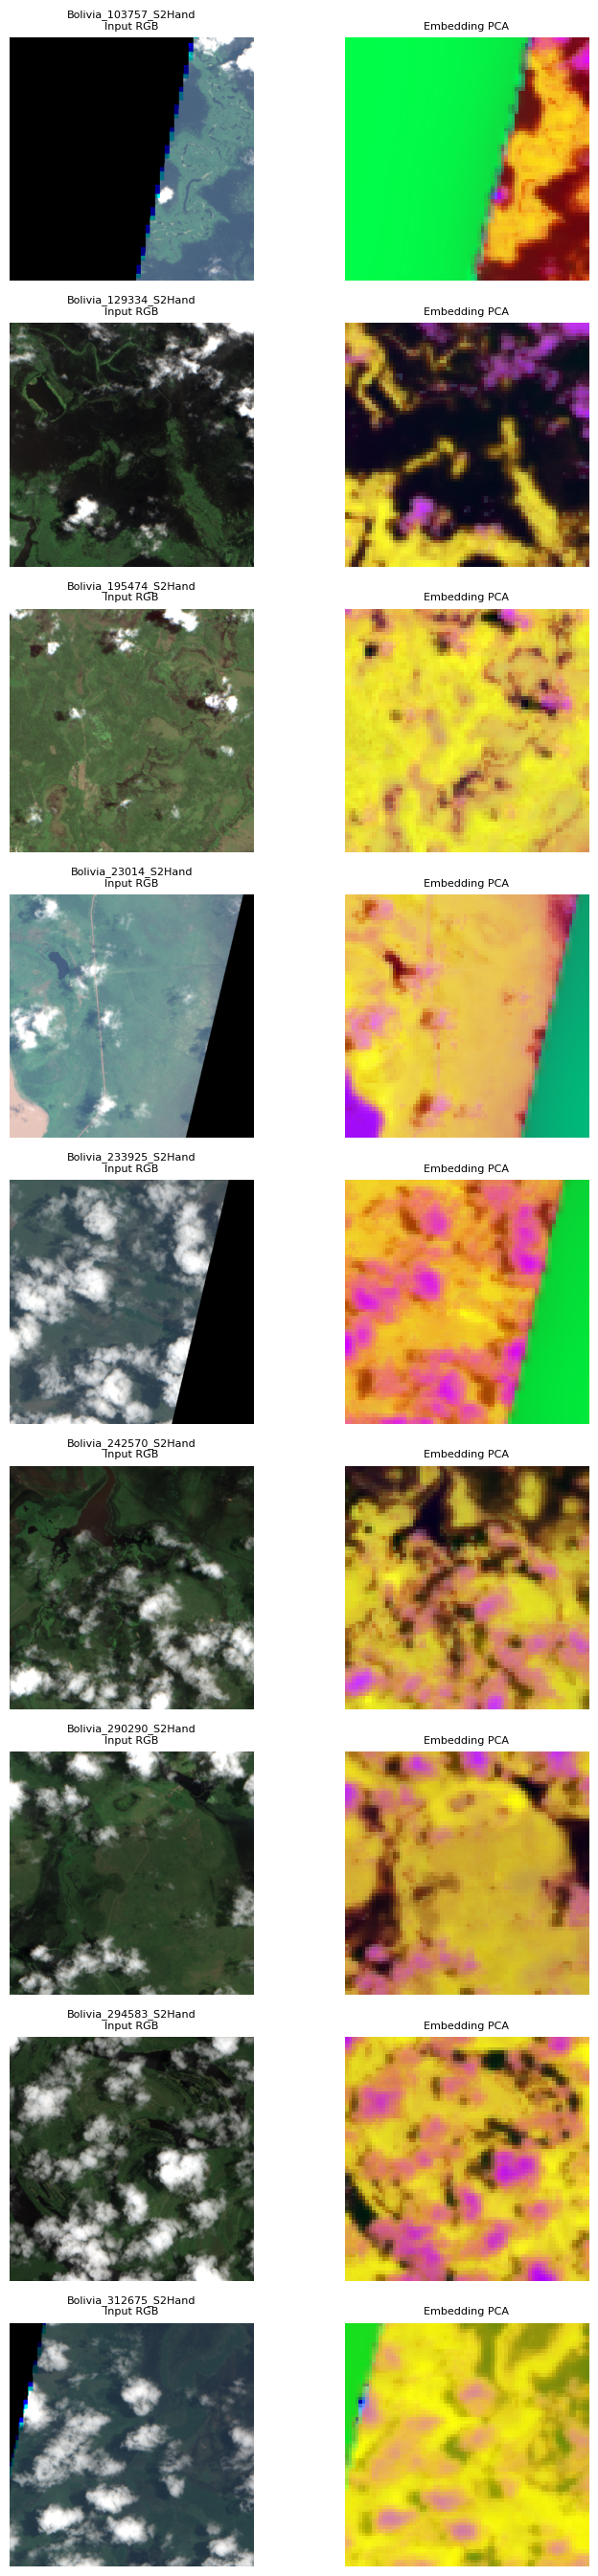

In [34]:
from sklearn.decomposition import PCA
from terratorch.datasets.utils import to_rgb

# Load a sample of embeddings for a joint PCA
n_samples = min(9, len(embed_files))
sample_files = embed_files[:n_samples]

embeddings = [load_embedding(f) for f in sample_files]
C, H, W = embeddings[0].shape

# Stack all patches and fit PCA globally
all_patches = np.concatenate(
    [e.reshape(C, H * W).T for e in embeddings], axis=0
)  # (N*H*W, C)
pca_global = PCA(n_components=3)
pca_global.fit(all_patches)
print(
    f"Explained variance by first 3 PCs: {pca_global.explained_variance_ratio_.sum():.1%}"
)


def apply_global_pca(emb, pca):
    C, H, W = emb.shape
    patches = emb.reshape(C, H * W).T
    reduced = pca.transform(patches).reshape(H, W, 3)
    for c in range(3):
        mn, mx = reduced[..., c].min(), reduced[..., c].max()
        reduced[..., c] = (reduced[..., c] - mn) / (mx - mn + 1e-8)
    return reduced


def load_rgb(embed_path):
    img_name = embed_path.name.replace("_embedding.tif", ".tif")
    img_path = dataset_path / "data/S2L1CHand" / img_name
    with rasterio.open(img_path) as src:
        rgb = src.read([4, 3, 2]).astype(np.float32)
    return to_rgb(rgb, [0, 1, 2])


fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 3))
for i, (f, emb) in enumerate(zip(sample_files, embeddings)):
    name = f.stem.replace("_embedding", "")
    axes[i, 0].imshow(load_rgb(f))
    axes[i, 0].set_title(f"{name}\nInput RGB", fontsize=8)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(apply_global_pca(emb, pca_global))
    axes[i, 1].set_title("Embedding PCA", fontsize=8)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Individual Embedding Channels

To understand what individual channels capture, we plot a selection of raw embedding channels as heatmaps. Different channels respond to different spatial features — some may highlight water bodies, vegetation edges, or built-up areas.

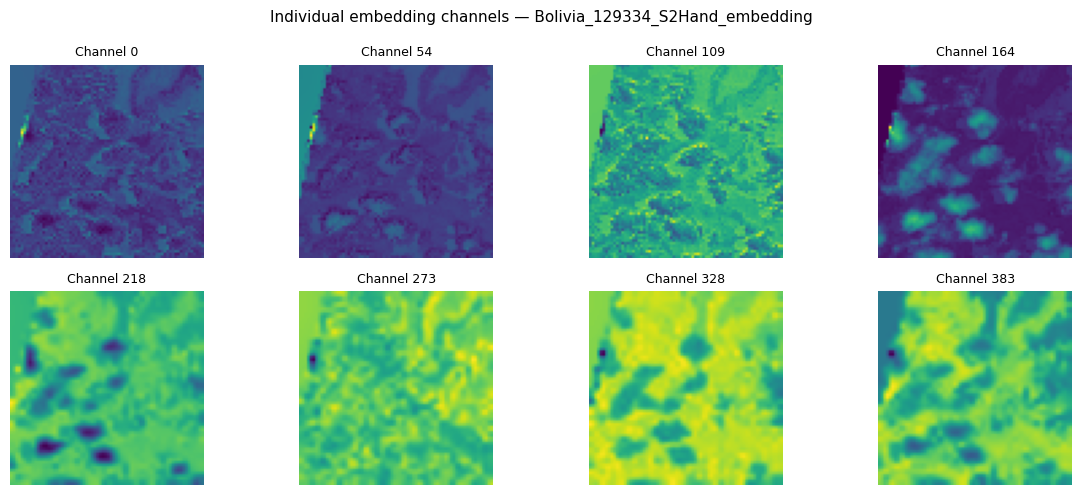

In [35]:
n_channels_to_show = 8
channel_indices = np.linspace(0, C - 1, n_channels_to_show, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for ax, ch in zip(axes.flat, channel_indices):
    ax.imshow(emb[ch], cmap="viridis")
    ax.set_title(f"Channel {ch}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Individual embedding channels — {sample_path.stem}", fontsize=11)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we ran THOR embedding generation via the TerraTorch CLI (`terratorch predict`) and visualized the resulting dense spatial embeddings using PCA and per-channel heatmaps. The embeddings capture rich spatial representations that can be used as features for downstream tasks such as change detection, clustering, or linear probing — without any task-specific fine-tuning.